
<h2 id="3.7-DSSD-%E6%95%B0%E6%8D%AE%E5%88%86%E6%9E%90">3.7 DSSD 数据分析</h2><ul>
<li>根据 3.6 节分析结果，重新组织事件结构。 对每个 DSSD，先完成单片内部的 x-y 配对与 multiplicity 事例重建，再给出每个入射粒子的入射位置 <code>(x,y)</code> 和能量 <code>e</code>。</li>
<li><code>hit</code> 表示该探测器中在当前配对规则下重建出的粒子数，<code>e</code> 表示分配给该粒子的重建能量。3.6 节已经完成单片内部的相对刻度统一与 multiplicity 相关能量偏移修正，因此本节可以直接在粒子层面讨论探测器间关联。</li>
</ul>
<div class="highlight"><pre><span></span><span class="c1">// det1</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">hit1</span><span class="p">;</span>
<span class="kt">double</span><span class="w"> </span><span class="n">e1</span><span class="p">[</span><span class="n">hit1</span><span class="p">];</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">x1</span><span class="p">[</span><span class="n">hit1</span><span class="p">],</span><span class="w"> </span><span class="n">y1</span><span class="p">[</span><span class="n">hit1</span><span class="p">];</span>

<span class="c1">// det2</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">hit2</span><span class="p">;</span>
<span class="kt">double</span><span class="w"> </span><span class="n">e2</span><span class="p">[</span><span class="n">hit2</span><span class="p">];</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">x2</span><span class="p">[</span><span class="n">hit2</span><span class="p">],</span><span class="w"> </span><span class="n">y2</span><span class="p">[</span><span class="n">hit2</span><span class="p">];</span>

<span class="c1">// det3</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">hit3</span><span class="p">;</span>
<span class="kt">double</span><span class="w"> </span><span class="n">e3</span><span class="p">[</span><span class="n">hit3</span><span class="p">];</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">x3</span><span class="p">[</span><span class="n">hit3</span><span class="p">],</span><span class="w"> </span><span class="n">y3</span><span class="p">[</span><span class="n">hit3</span><span class="p">];</span>
</pre></div>


In [ ]:
// %jsroot on
TFile *ipf = new TFile("./data/evt_16C.root");
TTree *tree = (TTree*)ipf->Get("tree");
TCanvas *c1 = new TCanvas("c1","c1",900,450);


<h3 id="%E5%85%A8%E9%83%A8%E4%BA%8B%E4%BB%B6">全部事件</h3><ul>
<li>将相邻探测器的重建能量作二维关联，可以看到望远镜中的 dE-E 结构。</li>
<li>这些二维关联一方面反映了不同粒子的能量损失规律，另一方面也混有粒子在探测器中发生散射或反应形成的连续本底。</li>
</ul>



<h3 id="$%5CDelta-E_1-:-%5CDelta-E_2$,-$%5CDelta-E_2-:-%5CDelta-E_3$">$\Delta E_1 : \Delta E_2$, $\Delta E_2 : \Delta E_3$</h3>


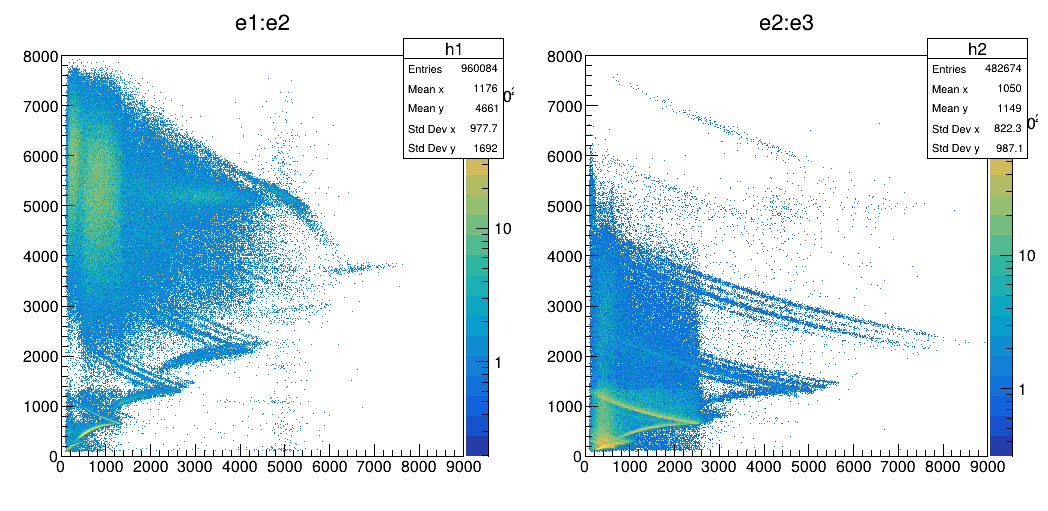

In [5]:
c1->SetWindowSize(1200,600);
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("e1:e2>>h1(1000,0,9000,1000,0,8000)","","colz");
gPad->SetLogz();
c1->cd(2);
tree->Draw("e2:e3>>h2(1000,0,9000,1000,0,8000)","","colz");
gPad->SetLogz();
c1->Draw();

<h3>一个重建粒子</h3><p>先选取相邻两层各有一个重建 hit 的事例，观察主条带和连续分布。连续分布可能含散射、反应、能量收集不完整及误配等成分，不能仅靠这张图确定来源。</p>

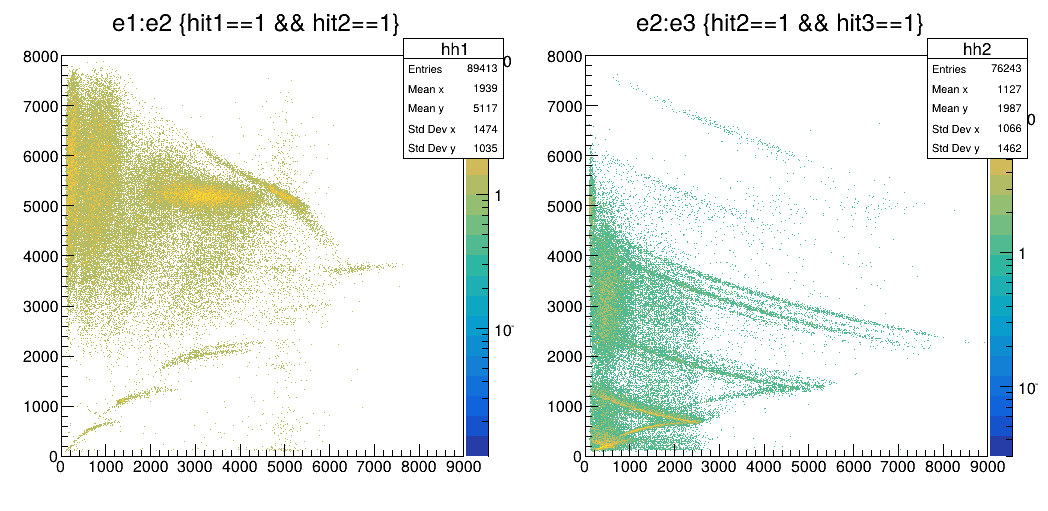

In [7]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("e1:e2>>hh1(1000,0,9000,1000,0,8000)","hit1==1 && hit2==1","colz");
gPad->SetLogz();
c1->cd(2);
tree->Draw("e2:e3>>hh2(1000,0,9000,1000,0,8000)","hit2==1 && hit3==1","colz");
gPad->SetLogz();
c1->Draw();


<h3 id="%E4%B8%A4%E4%B8%AA%E7%B2%92%E5%AD%90%E5%85%A5%E5%B0%84">两个粒子入射</h3><ul>
<li>相邻探测器之间已经形成较清晰的二维 dE-E 关联，但仍可以看到粒子在探测器中发生反应后形成的连续本底。</li>
</ul>
<p>此处 Draw 对两个数组按同一下标组成点，并没有完成跨探测器的粒子配对。这些图用于观察未经重新配对的关联；后文再检查能量排序导致的误配。</p>

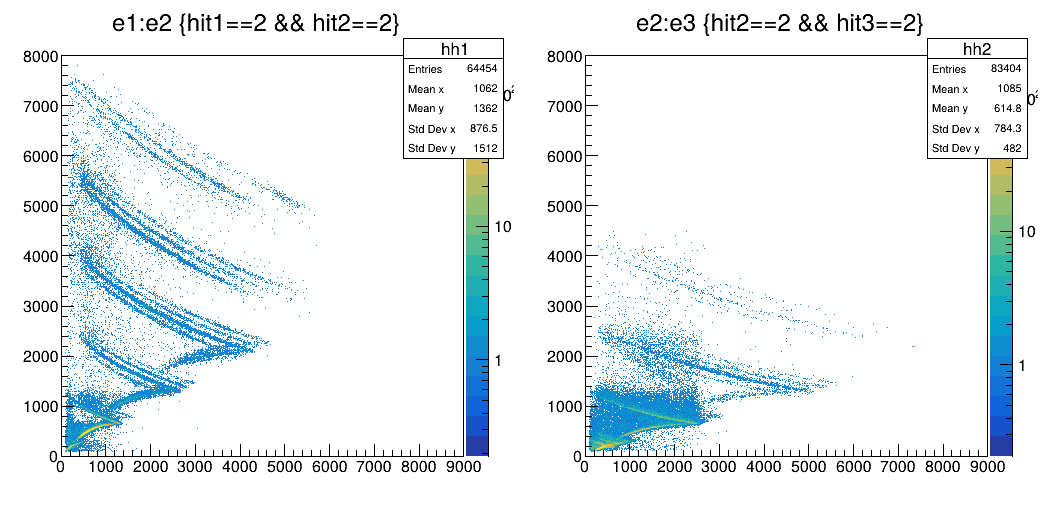

In [9]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("e1:e2>>hh1(1000,0,9000,1000,0,8000)","hit1==2 && hit2==2","colz");
gPad->SetLogz();
c1->cd(2);
tree->Draw("e2:e3>>hh2(1000,0,9000,1000,0,8000)","hit2==2 && hit3==2","colz");
gPad->SetLogz();
c1->Draw();


<h3 id="%E4%B8%A4%E4%B8%AA%E7%9B%B8%E9%82%BB%E6%8E%A2%E6%B5%8B%E5%99%A8%E4%B9%8B%E9%97%B4%E7%9A%84%E5%85%A5%E5%B0%84%E7%B2%92%E5%AD%90%E4%BD%8D%E7%BD%AE%E5%85%B3%E8%81%94%EF%BC%9A%E4%B8%80%E7%B2%92%E5%AD%90%E5%85%A5%E5%B0%84">两个相邻探测器之间的入射粒子位置关联：一粒子入射</h3><h3 id="%E4%B8%80%E4%B8%AA%E7%B2%92%E5%AD%90%E5%85%A5%E5%B0%84">一个粒子入射</h3>


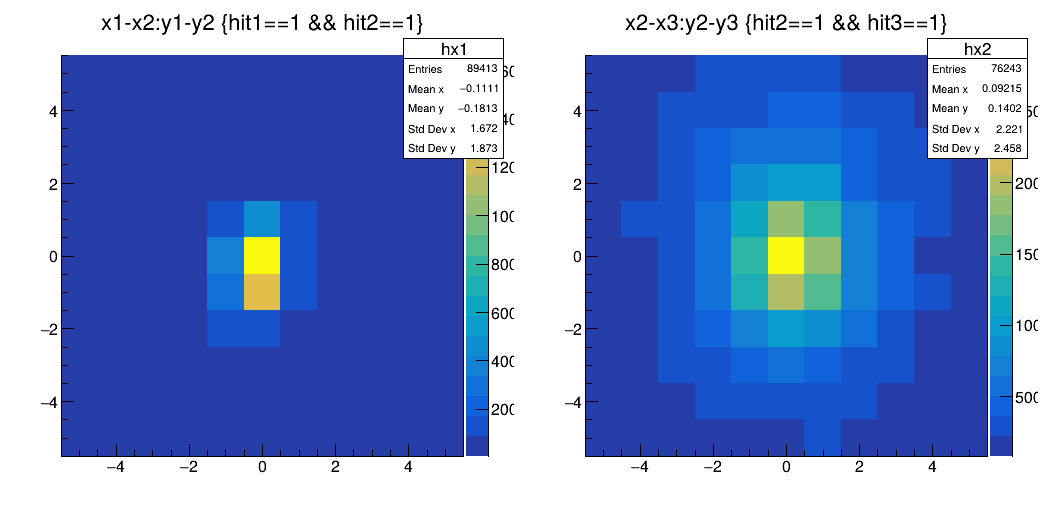

In [11]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("x1-x2:y1-y2>>hx1(11,-5.5,5.5,11,-5.5,5.5)","hit1==1 && hit2==1","colz");
c1->cd(2);
tree->Draw("x2-x3:y2-y3>>hx2(11,-5.5,5.5,11,-5.5,5.5)","hit2==1 && hit3==1","colz");
c1->Draw();


<h3 id="%E4%B8%A4%E4%B8%AA%E7%B2%92%E5%AD%90%E5%85%A5%E5%B0%84">两个粒子入射</h3>


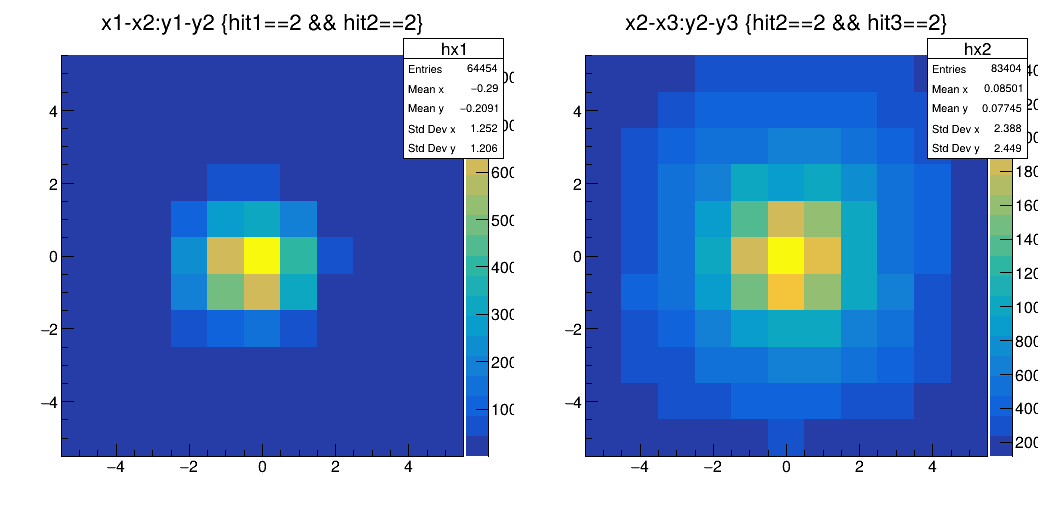

In [13]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("x1-x2:y1-y2>>hx1(11,-5.5,5.5,11,-5.5,5.5)","hit1==2 && hit2==2","colz");
c1->cd(2);
tree->Draw("x2-x3:y2-y3>>hx2(11,-5.5,5.5,11,-5.5,5.5)","hit2==2 && hit3==2","colz");
c1->Draw();

<p>下面用两个方向的条号差都不超过 2（整数条件 <code>abs(Δstrip)&lt;3</code>）选择位置相容的候选。它能抑制一部分不相容事例，但不是“未发生反应”的充分判据；还应考虑几何对准、角度及分辨。</p><p><img alt="探测器中反应与位置关联示意" src="fig/reaction_detector.png"/></p>


<h3 id="%E9%80%89%E6%8B%A9%E6%9C%AA%E5%9C%A8%E6%8E%A2%E6%B5%8B%E5%99%A8%E5%8F%8D%E5%BA%94%E4%BA%8B%E4%BB%B6">选择位置相容的候选事件</h3><ul>
<li>可以去除大量连续本底</li>
</ul>
<h3 id="%E4%B8%80%E4%B8%AA%E7%B2%92%E5%AD%90%E5%85%A5%E5%B0%84">一个粒子入射</h3>


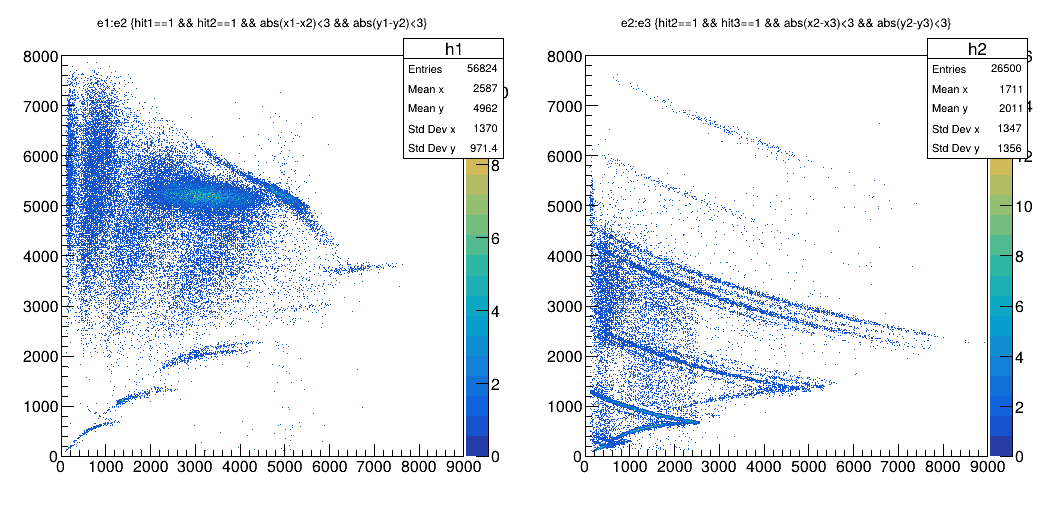

In [16]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("e1:e2>>h1(1000,0,9000,1000,0,8000)","hit1==1 && hit2==1 && abs(x1-x2)<3 && abs(y1-y2)<3","colz");
c1->cd(2);
tree->Draw("e2:e3>>h2(1000,0,9000,1000,0,8000)","hit2==1 && hit3==1 && abs(x2-x3)<3 && abs(y2-y3)<3","colz");
c1->Draw();


<h3 id="%E4%B8%A4%E4%B8%AA%E7%B2%92%E5%AD%90%E5%85%A5%E5%B0%84">两个粒子入射</h3>


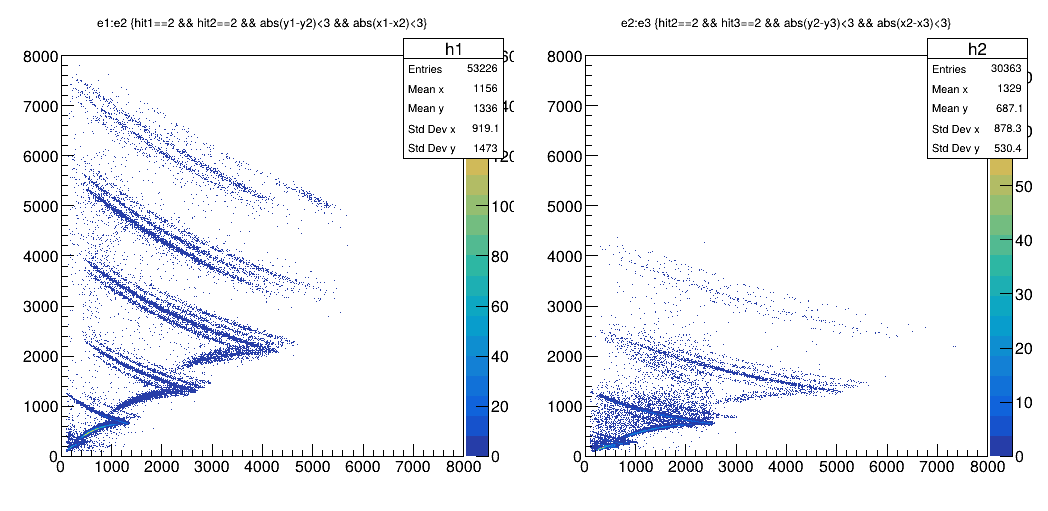

In [18]:
c1->Clear();
c1->Divide(2,1);
c1->cd(1);
tree->Draw("e1:e2>>h1(1000,0,8000,1000,0,8000)",
           "hit1==2 && hit2==2 && abs(y1-y2)<3 && abs(x1-x2)<3",
           "colz");
c1->cd(2);
tree->Draw("e2:e3>>h2(1000,0,8000,1000,0,8000)",
           "hit2==2 && hit3==2 && abs(y2-y3)<3 && abs(x2-x3)<3",
           "colz");
c1->Draw();


<h3 id="%E7%BB%9D%E5%AF%B9%E8%83%BD%E9%87%8F%E5%88%BB%E5%BA%A6">绝对能量刻度</h3><ul>
<li>3.6 节完成的是各探测器内部的相对刻度，只统一了同一片 DSSD 内不同条带的响应，并修正了 multiplicity 相关的能量偏移。 要进行实际的物理量提取，还需要进一步完成绝对能量刻度。</li>
<li>将实验得到的 <code>e1-e2</code>、<code>e2-e3</code> 二维关联，与根据能量损失规律计算得到的理论 dE-E 关联进行比较和拟合，从而确定各层探测器的实际能量刻度系数。</li>
<li>后面凡是需要利用能量信息进行粒子鉴别、事例选择和物理量提取的步骤，都应建立在绝对能量刻度已经完成的基础上。</li>
<li><img alt="" src="fig/pid_calibration.png" width="400"/></li>
</ul>
<p>绝对刻度还依赖粒子种类、有效探测器厚度和能量损失模型。相对幅度图本身可以先用于关联检查，但不能直接把坐标标为 MeV。</p>


<h3 id="%E4%B8%8D%E5%90%8C%E6%8E%A2%E6%B5%8B%E5%99%A8%E4%B9%8B%E9%97%B4%E7%9A%84%E4%BA%8B%E4%BB%B6%E5%AF%B9%E5%BA%94%E5%85%B3%E7%B3%BB">不同探测器之间的事件对应关系</h3>


In [21]:
tree->Scan("x2:x3:y2:y3:int(e2):int(e3)"," hit2==2 && hit3==2 ","",100,1);

***********************************************************************************************
*    Row   * Instance *        x2 *        x3 *        y2 *        y3 *   int(e2) *   int(e3) *
***********************************************************************************************
*        7 *        0 *         7 *         5 *        19 *        21 *       868 *      1445 *
*        7 *        1 *         6 *         3 *        17 *        17 *       562 *      1353 *
*       22 *        0 *        19 *        20 *        14 *        14 *       781 *      1720 *
*       22 *        1 *        16 *        15 *        10 *         7 *       176 *       378 *
*       36 *        0 *        12 *        13 *        11 *         4 *       689 *       523 *
*       36 *        1 *        11 *        11 *         7 *        16 *       232 *       141 *
*       44 *        0 *        22 *        12 *        12 *        16 *      1879 *      1979 *
*       44 *        1 *        17 *     


<ul>
<li>如事件 36 所示，<code>y2-y3</code> 的匹配关系可能是错误的。这是因为 DSSD2 和 DSSD3 中各自重建出的事件顺序，是按能量从高到低排列的；但两个探测器之间对应粒子的先后顺序，并不一定满足相同的能量排序。</li>
<li>实际上，粒子在 DSSD2 和 DSSD3 中的能量关系，取决于粒子种类、入射能量以及两个探测器的厚度。因此，仅按各探测器内部的能量大小排序，不能唯一确定不同探测器之间的正确对应关系；错误匹配会在 dE-E 图上形成落在正确关联关系之外的散点。</li>
</ul>
<ul>
<li>因此，不同探测器之间的匹配需要同时考虑几何关系和能量关系，当存在多个候选排列时：<ul>
<li>几何关系上，应选择由靶后多个探测器位置外推出的靶上位置，与由靶前 PPAC 计算得到的靶上位置更接近的组合；</li>
<li>能量关系上，应选择更符合相邻探测器之间正确 dE-E / PID 关系的组合；而这一步需要建立在绝对能量刻度已经完成的基础上。</li>
</ul>
</li>
</ul>
<p><strong>在完成不同探测器之间的事件匹配之后，便可在此基础上开展更进一步的物理分析，例如分析反应类型、构建不变质量谱等。</strong></p>
